In [76]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

In [77]:
### define forward model

def model_Qb(t_obs, Q, r, S, T, t0):
    """
    Forward model of boundary flux:
        t_obs: observed elapsed times since t0 [T]
        Q: pumping rate (positive for extraction) [L^3/T]
        r: radial distance(s) [L] (scalar or array)
        S: storage coefficient [-]
        t0: initial time
    
    Notes:
        - If any (t_obs - t0) <= 0, returns tiny values to keep residuals large

    """
    t_obs = np.asarray(t_obs, dtype=float)
    tau = t_obs - t0
    tiny = 1e-12
    if np.any(tau <= 0):
        return tiny * np.ones_like(t_obs)
    u = (r**2 * S) / (4.0 * T * tau)
    return Q * np.exp(-u)

In [78]:
### calculate analytic residuals and Jacobian matrix

def residuals_and_jacobian(params, t_obs, Qb_obs, Q, S, T, eps_floor=1e-12):
    """
    Returns (res, J) where:
      res_i = ln(Qb_obs_i) - ln(Qb_pred_i)
      J[:,0] = d res / d r
      J[:,1] = d res / d t0
    params = [r, t0]

    """
    r, t0 = params
    t_obs = np.asarray(t_obs, dtype=float)
    Qb_obs = np.asarray(Qb_obs, dtype=float)
    N = len(t_obs)

    # bounds: r <= 0, tau <= 0
    if r <= 0:
        N = len(t_obs)
        res = 1e6 * np.ones(N)
        J = np.zeros((N, 2))
        return res, J
    
    tau = t_obs - t0
    if np.any(tau <= 0):
        N = len(t_obs)
        res = 1e6 * np.ones(N)
        J = np.zeros((N, 2))
        return res, J

    # model prediction
    Qb_pred = model_Qb(t_obs, Q, r, S, T, t0)
    Qb_obs_safe = np.maximum(Qb_obs, eps_floor)   # floor values to avoid log(0)
    Qb_pred_safe = np.maximum(Qb_pred, eps_floor) # floor values to avoid log(0)

    # residuals in log-space
    res = np.log(Qb_obs_safe) - np.log(Qb_pred_safe)

    # from fwd theis
    u = (r**2 * S) / (4.0 * T * tau)
    du_dr = (r * S) / (2.0 * T * tau) 
    du_dt0 = (r**2 * S) / (4.0 * T * (tau**2))
    dlnQb_dr = -du_dr
    dlnQb_dt0 = -du_dt0

    # Jacobian matrix entries
    J_col_r = -dlnQb_dr
    J_col_t0 = -dlnQb_dt0

    J = np.vstack((J_col_r, J_col_t0)).T  # shape (N, 2)
    return res, J

In [79]:
### define least-squares wrapper functions

def fun_for_ls(params, t_obs, Qb_obs, Q, S, T):
    res, _ = residuals_and_jacobian(params, t_obs, Qb_obs, Q, S, T)
    return res

def jac_for_ls(params, t_obs, Qb_obs, Q, S, T):
    _, J = residuals_and_jacobian(params, t_obs, Qb_obs, Q, S, T)
    return J

In [80]:
### generate synthetic data

# "true" synthetic parameters
Q_true = 1.0e-3      # m^3/s
r_true = 2.5         # m
S = 1e-4             # dimensionless (known)
T = 1e-3             # m^2/s (known)
t0_true = 0.0        # seconds (pump started at time 0)

# observation times (seconds) - choose spread so tau varies
t_obs_full = np.array([10.0, 100.0])

# generate clean boundary flux
Qb_clean_full = model_Qb(t_obs_full, Q_true, r_true, S, T, t0_true)

# initial guesses 
# bounds: r > 0, t0 < min(t_obs)
r0 = 1.0
t0_guess = -5.0
x0 = np.array([r0, t0_guess])
lower_bounds = [1e-9, -1e9]
upper_bounds = [1e6, np.min(t_obs_full) - 1e-9]

In [84]:
### evaluate identifiability

Qb_obs_full = Qb_clean_full.copy()  # perfect data

# run least_squares using Jacobian
res_lsq = least_squares(fun_for_ls, x0, jac=jac_for_ls,
                        bounds=(lower_bounds, upper_bounds),
                        args=(t_obs_full, Qb_obs_full, Q_true, S, T),
                        xtol=1e-12, ftol=1e-12, gtol=1e-12, verbose=2)

theta_hat = res_lsq.x

print("fitted parameters (r, t0) =", theta_hat)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.8295e-05                                    4.72e+01    
       1              4         1.7520e-05      8.08e-05       1.41e+00       4.78e+01    
       2              5         6.1014e-07      1.69e-05       7.23e-01       8.74e+02    
       3              6         2.8222e-07      3.28e-07       6.33e-01       3.36e+01    
       4              7         2.6309e-07      1.91e-08       1.68e-01       3.43e-03    
       5              8         2.2810e-07      3.50e-08       4.00e-01       2.11e+00    
       6              9         1.6649e-07      6.16e-08       7.82e-01       1.09e+01    
       7             10         7.5594e-08      9.09e-08       1.50e+00       5.61e+01    
       8             11         1.4694e-08      6.09e-08       2.32e+00       2.27e+02    
       9             12         4.5683e-10      1.42e-08       2.73e-01       1.60e+00    

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.8295e-05                                    4.72e+01    
       1              4         1.7520e-05      8.08e-05       1.41e+00       4.78e+01    
       2              5         6.1014e-07      1.69e-05       7.23e-01       8.74e+02    
       3              6         2.8222e-07      3.28e-07       6.33e-01       3.36e+01    
       4              7         2.6309e-07      1.91e-08       1.68e-01       3.43e-03    
       5              8         2.2810e-07      3.50e-08       4.00e-01       2.11e+00    
       6              9         1.6649e-07      6.16e-08       7.82e-01       1.09e+01    
       7             10         7.5594e-08      9.09e-08       1.50e+00       5.61e+01    
       8             11         1.4694e-08      6.09e-08       2.32e+00       2.27e+02    
       9             12         4.5683e-10      1.42e-08       2.73e-01       1.60e+00    

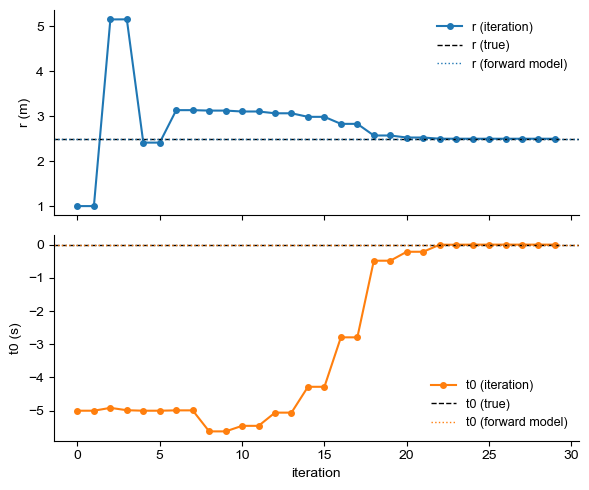

In [86]:
### record every parameter evaluation

params_history = []

def make_recording_wrappers(fun, jac):
    """
    Wrap fun and jac so that whenever least_squares calls them with a params vector,
    a copy is recored into params_history. 
    
    Returns wrapped_fun, wrapped_jac.
    """
    def wrapped_fun(params, *args, **kwargs):
        params_history.append(np.asarray(params).copy())
        return fun(params, *args, **kwargs)
    def wrapped_jac(params, *args, **kwargs):

        params_history.append(np.asarray(params).copy())
        return jac(params, *args, **kwargs)
    return wrapped_fun, wrapped_jac

# create wrapped versions
fun_wrapped, jac_wrapped = make_recording_wrappers(fun_for_ls, jac_for_ls)

# run least squares optimization
params_history.clear()   # clear history
Qb_obs_full = Qb_clean_full.copy()  # example data

res_lsq = least_squares(fun_wrapped, x0, jac=jac_wrapped,
                        bounds=(lower_bounds, upper_bounds),
                        args=(t_obs_full, Qb_obs_full, Q_true, S, T),
                        xtol=1e-8, ftol=1e-8, gtol=1e-8, verbose=2)

theta_hat = res_lsq.x
rounded_theta = np.round(theta_hat, 1)
print("fitted parameters (r, t0) =", rounded_theta)

# convert to array
hist = np.asarray(params_history)  # shape (n_evals, 2)

r_hist = hist[:, 0]
t0_hist = hist[:, 1]
iters = np.arange(len(hist))

# pot r and t0 vs iteration index
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# r history
ax[0].plot(iters, r_hist, '-o', markersize=4, label='r (iteration)', color='C0')
ax[0].axhline(r_true, color='k', linestyle='--', linewidth=1, label='r (true)')
ax[0].axhline(rounded_theta[0], color='C0', linestyle=':', linewidth=1, label='r (forward model)')
ax[0].set_ylabel('r (m)')
ax[0].legend(frameon=False, fontsize=9)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# t0 history
ax[1].plot(iters, t0_hist, '-o', markersize=4, label='t0 (iteration)', color='C1')
ax[1].axhline(t0_true, color='k', linestyle='--', linewidth=1, label='t0 (true)')
ax[1].axhline(rounded_theta[1], color='C1', linestyle=':', linewidth=1, label='t0 (forward model)')
ax[1].set_ylabel('t0 (s)')
ax[1].set_xlabel('iteration')
ax[1].legend(frameon=False, fontsize=9)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()